<a href="https://colab.research.google.com/github/Mr-Kondo/vlm-lora-qlora-comparison/blob/main/notebooks/vlm_lora_qlora_comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# BASE vs LoRA vs QLoRA — Document-Image → JSON

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Mr-Kondo/vlm-lora-qlora-comparison/blob/main/notebooks/vlm_lora_qlora_comparison.ipynb)

Fine-tunes a vision-language model to turn receipt photographs into structured JSON, and compares
three conditions on **four axes at once**:

| Axis | What is measured |
|---|---|
| Generation quality | JSON validity, document exact match, field accuracy / precision / recall / F1, CER, WER, evaluation loss |
| GPU VRAM | Peak CUDA memory allocated during training |
| Training time | Monotonic wall-clock duration of the training phase |
| Trainable parameters | Counted on the instantiated model, total / trainable / ratio |

The three conditions:

1. **BASE** — the pretrained VLM, no fine-tuning (0 trainable parameters, no training cost).
2. **LoRA** — the same base model in 16-bit, LoRA adapters trained.
3. **QLoRA** — the *same* base model loaded 4-bit NF4, an *equivalent* LoRA adapter trained.

**This notebook does not implement training.** It drives `scripts/train.py` and `scripts/evaluate.py`,
then reads the JSON/JSONL artifacts those write. Both methods go through one shared training entry
point, so the LoRA/QLoRA difference is the method, not two separately written pipelines.

> **Runtime:** a GPU runtime is required. On an L4/A100 the two training runs take roughly 1–2 hours
> combined with the default config; on a T4 expect appreciably longer. To rehearse the whole flow in
> a few minutes first, use the smoke-test switches noted before the training cells.

## 0 · Environment

In [ ]:
import subprocess

try:
    result = subprocess.run(["nvidia-smi"], capture_output=True, text=True, check=False)
    print(result.stdout or result.stderr or "nvidia-smi produced no output")
except FileNotFoundError:
    print("nvidia-smi not found: this runtime has no NVIDIA GPU.\n"
          "Training and VRAM measurement both require a GPU runtime "
          "(Runtime -> Change runtime type -> GPU).")

Sat Sep 12 15:56:42 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          Off |   00000000:00:05.0 Off |                    0 |
| N/A   31C    P0             50W /  400W |       0MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [ ]:
import os, subprocess, sys

# Opening this notebook straight from GitHub (the "Open in Colab" badge) gives you
# the notebook but not the repository, so fetch the repository if it is missing.
REPO_URL = "https://github.com/Mr-Kondo/vlm-lora-qlora-comparison.git"
DEFAULT_DIR = "/content/vlm-lora-qlora-comparison"
PROJECT_DIR = os.environ.get("VLM_FT_PROJECT_DIR", DEFAULT_DIR)


def is_project(path):
    return os.path.isfile(os.path.join(path, "scripts", "train.py"))


# 1. already inside a checkout? (running locally, or the repo was cloned/mounted)
if not is_project(PROJECT_DIR):
    for candidate in (os.getcwd(), os.path.dirname(os.getcwd())):
        if is_project(candidate):
            PROJECT_DIR = candidate
            break

# 2. still missing: clone it (the usual Colab path)
if not is_project(PROJECT_DIR):
    print(f"cloning {REPO_URL} -> {PROJECT_DIR}")
    subprocess.run(["git", "clone", "--depth", "1", REPO_URL, PROJECT_DIR], check=True)

if not is_project(PROJECT_DIR):
    raise SystemExit(
        f"Project not found at {PROJECT_DIR!r} and the clone did not produce it.\n"
        "Clone or mount the repository manually, then set PROJECT_DIR "
        "(or the VLM_FT_PROJECT_DIR environment variable)."
    )

os.chdir(PROJECT_DIR)
sys.path.insert(0, os.path.join(PROJECT_DIR, "src"))
print("project:", PROJECT_DIR)
print(sorted(os.listdir(PROJECT_DIR)))

cloning https://github.com/Mr-Kondo/vlm-lora-qlora-comparison.git -> /content/vlm-lora-qlora-comparison
project: /content/vlm-lora-qlora-comparison
['.git', '.gitignore', 'README.ja.md', 'README.md', 'configs', 'notebooks', 'pyproject.toml', 'requirements-dev.txt', 'requirements.txt', 'scripts', 'src', 'tests']


In [ ]:
# Install dependencies. torch/torchvision are left alone on purpose: Colab ships
# them matched to the runtime CUDA build and reinstalling can break that match.
%pip install -q -r requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 61.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 158.7/158.7 kB 17.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 116.3 MB/s eta 0:00:00


### Dependency conflict Colab needs fixed

One preinstalled package has to go before training will work. The cell below explains why and is a
no-op on any environment that does not have the problem.

In [ ]:
# Colab preinstalls torchao pinned to its own torch build. peft probes torchao
# for every module it wraps, and that probe RAISES on an out-of-range version
# instead of returning False -- so an old torchao breaks LoRA injection
# entirely. This project never uses torchao (4-bit goes through bitsandbytes),
# so removing it is the minimal fix. Upgrading works too, but on Colab it can
# pull a torch build that does not match the runtime.
#
# Run this BEFORE anything imports peft or torchao.
import importlib.util
import subprocess
import sys

if importlib.util.find_spec("torchao") is None:
    print("torchao not installed; nothing to do")
else:
    from peft.import_utils import is_torchao_available

    try:
        is_torchao_available()
        print("torchao is installed and accepted by peft; leaving it alone")
    except ImportError as exc:
        print(f"{exc}\nremoving torchao (unused by this project)...")
        subprocess.run([sys.executable, "-m", "pip", "uninstall", "-y", "-q", "torchao"],
                       check=False)
        is_torchao_available.cache_clear()          # the probe is lru_cached
        try:
            is_torchao_available()
            print("torchao removed; peft can inject LoRA adapters now")
        except ImportError as still_broken:
            print(f"\nSTILL BROKEN: {still_broken}\n"
                  "torchao is most likely already imported in this kernel, so removing the\n"
                  "files was not enough. Use Runtime -> Restart session, then run this cell\n"
                  "again before the cell that imports peft.")

Found an incompatible version of torchao. Found version 0.10.0, but only versions above 0.16.0 are supported
removing torchao (unused by this project)...
torchao removed; peft can inject LoRA adapters now


In [ ]:
import torch, transformers, peft, datasets, accelerate
print("torch        ", torch.__version__, "| CUDA:", torch.version.cuda)
print("transformers ", transformers.__version__)
print("peft         ", peft.__version__)
print("datasets     ", datasets.__version__)
print("accelerate   ", accelerate.__version__)
try:
    import bitsandbytes
    print("bitsandbytes ", bitsandbytes.__version__)
except Exception as exc:
    print("bitsandbytes  UNAVAILABLE ->", exc, "\n  QLoRA cannot run without it.")

if torch.cuda.is_available():
    props = torch.cuda.get_device_properties(0)
    print(f"\nGPU: {props.name} | {props.total_memory / 1024**3:.1f} GiB | "
          f"capability {props.major}.{props.minor} | bf16: {torch.cuda.is_bf16_supported()}")
else:
    print("\nNo CUDA device. Training and VRAM measurement both require a GPU runtime.")

torch         2.11.0+cu128 | CUDA: 12.8
transformers  5.16.1
peft          0.20.0
datasets      4.8.5
accelerate    1.14.0
bitsandbytes  0.50.2

GPU: NVIDIA A100-SXM4-80GB | 79.3 GiB | capability 8.0 | bf16: True


## 1 · The controlled comparison, before anything runs

`configs/lora.yaml` and `configs/qlora.yaml` both inherit from `configs/base.yaml`. Everything that
could confound the comparison — model id and revision, dataset and splits, prompt, target format,
seed, epochs, effective batch size, LoRA rank/alpha/dropout/target modules, optimizer, LR schedule,
evaluation schedule, generation settings — is defined once in the parent. The two child files should
therefore differ in nothing but the method name and the quantization block.

In [ ]:
!diff configs/lora.yaml configs/qlora.yaml || true

1c1,2
< # LoRA: base weights kept in the 16-bit compute dtype, LoRA adapters trained.
---
> # QLoRA: the SAME base model loaded with 4-bit NF4 double quantization, then
> # prepared for k-bit training, with an otherwise identical LoRA adapter.
3c4
< method: lora
---
> method: qlora
6c7,10
<   load_in_4bit: false
---
>   load_in_4bit: true
>   bnb_4bit_quant_type: nf4
>   bnb_4bit_use_double_quant: true
>   bnb_4bit_compute_dtype: auto


In [ ]:
from vlm_ft.config import config_fingerprint, load_config

EXCLUDE = ("method", "quantization", "_config_path", "_parent_config")
lora_cfg, qlora_cfg = load_config("configs/lora.yaml"), load_config("configs/qlora.yaml")

print("shared-config fingerprint (method-specific keys excluded)")
print("  lora :", config_fingerprint(lora_cfg, EXCLUDE))
print("  qlora:", config_fingerprint(qlora_cfg, EXCLUDE))
print("  identical:", config_fingerprint(lora_cfg, EXCLUDE) == config_fingerprint(qlora_cfg, EXCLUDE))

print("\nheld identical:")
for section in ("experiment", "model", "data", "prompt", "training", "lora", "generation", "evaluation"):
    same = lora_cfg[section].to_dict() == qlora_cfg[section].to_dict()
    print(f"  {section:<12} {'same' if same else 'DIFFERS'}")

print("\nkey shared settings:")
for path in (("model", "id"), ("model", "revision"), ("data", "dataset_id"), ("experiment", "seed"),
             ("training", "num_train_epochs"), ("training", "learning_rate"), ("training", "optim"),
             ("lora", "r"), ("lora", "alpha"), ("lora", "dropout"), ("lora", "target_scope")):
    print(f"  {'.'.join(path):<28} {lora_cfg[path[0]][path[1]]}")

shared-config fingerprint (method-specific keys excluded)
  lora : 657e649523fe4198
  qlora: 657e649523fe4198
  identical: True

held identical:
  experiment   same
  model        same
  data         same
  prompt       same
  training     same
  lora         same
  generation   same
  evaluation   same

key shared settings:
  model.id                     HuggingFaceTB/SmolVLM-Instruct
  model.revision               main
  data.dataset_id              naver-clova-ix/cord-v2
  experiment.seed              42
  training.num_train_epochs    2
  training.learning_rate       0.0002
  training.optim               adamw_torch
  lora.r                       16
  lora.alpha                   32
  lora.dropout                 0.05
  lora.target_scope            text_model


## 2 · Fetch the base model and the dataset

Downloading up front keeps transfer time out of the measured training duration and pins the run to
one resolved commit SHA. The ~24 GB of ONNX exports in the model repo are skipped.

In [ ]:
!python scripts/download_model.py --config configs/base.yaml

2026-09-12 15:57:15,352 INFO httpx | HTTP Request: GET https://huggingface.co/api/agent-harnesses "HTTP/1.1 200 OK"
2026-09-12 15:57:15,455 INFO httpx | HTTP Request: GET https://huggingface.co/api/models/HuggingFaceTB/SmolVLM-Instruct/revision/main "HTTP/1.1 200 OK"
2026-09-12 15:57:15,458 INFO download | resolved HuggingFaceTB/SmolVLM-Instruct@main -> 81cd9a775a4d644f2faf4e7becff4559b46b14c7
2026-09-12 15:57:15,569 INFO httpx | HTTP Request: GET https://huggingface.co/api/models/HuggingFaceTB/SmolVLM-Instruct/tree/81cd9a775a4d644f2faf4e7becff4559b46b14c7?recursive=true&expand=false "HTTP/1.1 200 OK"
Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 14 files:   0% 0/14 [00:00<?, ?it/s]2026-09-12 15:57:15,677 INFO httpx | HTTP Request: HEAD https://huggingface.co/HuggingFaceTB/SmolVLM-Instruct/resolve/81cd9a775a4d644f2faf4e7becff4559b46b14c7/.gitattributes "HTTP/1.1 307 Temporary Redirect"
2026-09-12 15:57:15,694 INFO httpx | HTTP Request: HEAD ht

## 3 · Train

One entry point, one `--method` flag. Everything downstream of that flag is shared code.

**Smoke test first (recommended).** Append these to either command to rehearse the whole flow in a
couple of minutes before committing to the real run — then re-run without them:

```
--set training.max_steps=4 --set data.max_train_samples=8 --set data.max_eval_samples=4
```

**If you hit CUDA OOM**, lower the image budget or the sequence cap rather than changing anything
that differs between the methods — and apply the same change to *both* runs:

```
--set data.image.longest_edge=512 --set data.max_seq_length=1024
```

### 3a · LoRA

In [ ]:
!python scripts/train.py --method lora --config configs/lora.yaml

2026-09-12 15:57:51,231 INFO train | method=lora (base weights held in the 16-bit compute dtype; LoRA adapters trained)
2026-09-12 15:57:51,231 INFO train | config=configs/lora.yaml output=outputs/lora
2026-09-12 15:57:57,216 INFO numexpr.utils | NumExpr defaulting to 12 threads.
2026-09-12 15:57:59,213 INFO train | compute dtype=bfloat16
2026-09-12 15:57:59,249 INFO datasets | TensorFlow version 2.20.0 available.
2026-09-12 15:57:59,250 INFO datasets | JAX version 0.11.1 available.
2026-09-12 15:57:59,713 INFO httpx | HTTP Request: HEAD https://huggingface.co/datasets/naver-clova-ix/cord-v2/resolve/main/README.md "HTTP/1.1 307 Temporary Redirect"
2026-09-12 15:57:59,713 WARNING huggingface_hub.utils._http | Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
2026-09-12 15:57:59,723 INFO httpx | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/datasets/naver-clova-ix/cord-v2/7f0115a4b758a71

### 3b · QLoRA

In [ ]:
!python scripts/train.py --method qlora --config configs/qlora.yaml

2026-09-12 16:05:21,392 INFO train | method=qlora (base weights quantized to 4-bit NF4; identical LoRA adapters trained)
2026-09-12 16:05:21,392 INFO train | config=configs/qlora.yaml output=outputs/qlora
2026-09-12 16:05:27,486 INFO numexpr.utils | NumExpr defaulting to 12 threads.
2026-09-12 16:05:29,536 INFO train | compute dtype=bfloat16
2026-09-12 16:05:29,574 INFO datasets | TensorFlow version 2.20.0 available.
2026-09-12 16:05:29,575 INFO datasets | JAX version 0.11.1 available.
2026-09-12 16:05:30,029 INFO httpx | HTTP Request: HEAD https://huggingface.co/datasets/naver-clova-ix/cord-v2/resolve/main/README.md "HTTP/1.1 307 Temporary Redirect"
2026-09-12 16:05:30,030 WARNING huggingface_hub.utils._http | Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
2026-09-12 16:05:30,039 INFO httpx | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/datasets/naver-clova-ix/cord-v2/7f0115a4b758

## 4 · Evaluate all three variants on the same held-out test set

Identical prompt, identical test split, identical preprocessing, identical greedy generation
settings, identical scoring code. The only thing that changes is the model under test.

`--model-variant qlora` evaluates against 4-bit base weights by default, which is QLoRA's actual
deployable form. Add `--quantization none` to score the QLoRA adapter on a 16-bit base instead, if
you want to separate the training effect from the inference effect.

In [ ]:
!python scripts/evaluate.py --model-variant base --config configs/base.yaml

2026-09-12 16:14:14,976 INFO numexpr.utils | NumExpr defaulting to 12 threads.
2026-09-12 16:14:15,420 INFO datasets | TensorFlow version 2.20.0 available.
2026-09-12 16:14:15,421 INFO datasets | JAX version 0.11.1 available.
2026-09-12 16:14:15,907 INFO httpx | HTTP Request: HEAD https://huggingface.co/datasets/naver-clova-ix/cord-v2/resolve/main/README.md "HTTP/1.1 307 Temporary Redirect"
2026-09-12 16:14:15,919 INFO httpx | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/datasets/naver-clova-ix/cord-v2/7f0115a4b758a71d6473b8d085751692da2fef98/README.md "HTTP/1.1 200 OK"
2026-09-12 16:14:16,025 INFO httpx | HTTP Request: HEAD https://huggingface.co/datasets/naver-clova-ix/cord-v2/resolve/7f0115a4b758a71d6473b8d085751692da2fef98/cord-v2.py "HTTP/1.1 404 Not Found"
2026-09-12 16:14:16,025 WARNING huggingface_hub.utils._http | Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
2026-09-12 1

In [ ]:
!python scripts/evaluate.py --model-variant lora --config configs/lora.yaml

2026-09-12 16:34:18,366 INFO numexpr.utils | NumExpr defaulting to 12 threads.
2026-09-12 16:34:20,468 INFO datasets | TensorFlow version 2.20.0 available.
2026-09-12 16:34:20,469 INFO datasets | JAX version 0.11.1 available.
2026-09-12 16:34:20,942 INFO httpx | HTTP Request: HEAD https://huggingface.co/datasets/naver-clova-ix/cord-v2/resolve/main/README.md "HTTP/1.1 307 Temporary Redirect"
2026-09-12 16:34:20,951 INFO httpx | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/datasets/naver-clova-ix/cord-v2/7f0115a4b758a71d6473b8d085751692da2fef98/README.md "HTTP/1.1 200 OK"
2026-09-12 16:34:21,056 INFO httpx | HTTP Request: HEAD https://huggingface.co/datasets/naver-clova-ix/cord-v2/resolve/7f0115a4b758a71d6473b8d085751692da2fef98/cord-v2.py "HTTP/1.1 404 Not Found"
2026-09-12 16:34:21,056 WARNING huggingface_hub.utils._http | Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
2026-09-12 1

In [ ]:
!python scripts/evaluate.py --model-variant qlora --config configs/qlora.yaml

2026-09-12 16:50:43,551 INFO numexpr.utils | NumExpr defaulting to 12 threads.
2026-09-12 16:50:45,678 INFO datasets | TensorFlow version 2.20.0 available.
2026-09-12 16:50:45,679 INFO datasets | JAX version 0.11.1 available.
2026-09-12 16:50:46,163 INFO httpx | HTTP Request: HEAD https://huggingface.co/datasets/naver-clova-ix/cord-v2/resolve/main/README.md "HTTP/1.1 307 Temporary Redirect"
2026-09-12 16:50:46,173 INFO httpx | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/datasets/naver-clova-ix/cord-v2/7f0115a4b758a71d6473b8d085751692da2fef98/README.md "HTTP/1.1 200 OK"
2026-09-12 16:50:46,274 INFO httpx | HTTP Request: HEAD https://huggingface.co/datasets/naver-clova-ix/cord-v2/resolve/7f0115a4b758a71d6473b8d085751692da2fef98/cord-v2.py "HTTP/1.1 404 Not Found"
2026-09-12 16:50:46,574 INFO httpx | HTTP Request: HEAD https://s3.amazonaws.com/datasets.huggingface.co/datasets/datasets/naver-clova-ix/cord-v2/naver-clova-ix/cord-v2.py "HTTP/1.1 404 Not Found"
2026-09-12 16:5

## 5 · Load the artifacts

From here on the notebook only *reads* what the scripts wrote. Nothing is recomputed and nothing is
estimated: an unmeasured value stays `None` and renders as `N/A`.

In [ ]:
import json
import matplotlib.pyplot as plt
import pandas as pd
from vlm_ft import report

OUTPUT_ROOT = load_config("configs/base.yaml").experiment.output_root
comparison = report.build_comparison(OUTPUT_ROOT)
variants   = comparison["variants"]
analysis   = comparison["analysis"]

for name, record in variants.items():
    bits = [f"eval={'yes' if record['eval_available'] else 'NO'}"]
    if name != "base":
        bits.append(f"training={'yes' if record['training_available'] else 'NO'}")
    print(f"{name:<6} {' | '.join(bits)}")

if comparison["missing_artifacts"]:
    print("\nmissing artifacts (these become N/A, never invented):")
    for path in comparison["missing_artifacts"]:
        print("  -", path)

base   eval=yes
lora   eval=yes | training=yes
qlora  eval=yes | training=yes


## 6 · Final comparison table

In [ ]:
rows = comparison["table"]
display_table = pd.DataFrame([
    {
        "Metric": row["metric"],
        "BASE": report.format_value(row["key"], row["base"]),
        "LoRA": report.format_value(row["key"], row["lora"]),
        "QLoRA": report.format_value(row["key"], row["qlora"]),
    }
    for row in rows
])
display_table

,Metric,BASE,LoRA,QLoRA
0,JSON validity rate,0.7500,0.9900,0.9800
1,Document exact match,0.0000,0.0900,0.0000
2,Field accuracy,0.1660,0.5457,0.3705
3,Field precision,0.1024,0.6132,0.4252
4,Field recall,0.1783,0.5849,0.3997
5,Field F1,0.1301,0.5987,0.4120
6,CER,1.5862,0.1803,0.2062
7,WER,1.8781,0.3353,0.4209
8,Evaluation loss,0.7238,0.1641,0.2420
9,Peak training VRAM (GiB),N/A,9.276,8.416


In [ ]:
print(comparison["markdown_table"])

| Metric | BASE | LoRA | QLoRA |
|---|---:|---:|---:|
| JSON validity rate | 0.7500 | 0.9900 | 0.9800 |
| Document exact match | 0.0000 | 0.0900 | 0.0000 |
| Field accuracy | 0.1660 | 0.5457 | 0.3705 |
| Field precision | 0.1024 | 0.6132 | 0.4252 |
| Field recall | 0.1783 | 0.5849 | 0.3997 |
| Field F1 | 0.1301 | 0.5987 | 0.4120 |
| CER | 1.5862 | 0.1803 | 0.2062 |
| WER | 1.8781 | 0.3353 | 0.4209 |
| Evaluation loss | 0.7238 | 0.1641 | 0.2420 |
| Peak training VRAM (GiB) | N/A | 9.276 | 8.416 |
| Training time (s) | N/A | 430.0 (7m 09s) | 513.0 (8m 33s) |
| Total parameters | 2,246,272,880 | 2,264,360,816 | 2,264,360,816 |
| Trainable parameters | 0 | 18,087,936 | 18,087,936 |
| Trainable parameter ratio (%) | 0.0000% | 0.7988% | 0.7988% |


## 7 · Verify the two runs really were matched

The checks below compare the *recorded* facts of the two finished runs — not the intent in the
config files. `target_modules_match` compares a hash of the fully-qualified module names that LoRA
actually wrapped on each instantiated model.

In [ ]:
check = analysis["controlled_comparison"]

if not check.get("checked"):
    print("skipped:", check.get("reason"))
else:
    print("ALL MATCHED" if check["all_matched"] else f"MISMATCH in: {check['failed']}")
    for name, ok in check["checks"].items():
        print(f"  [{'ok' if ok else 'XX'}] {name}")

print("\nDifferences that cannot be eliminated (inherent to QLoRA), and why:")
for item in report.DOCUMENTED_DIFFERENCES:
    print(f"\n  {item['parameter']}")
    print(f"    LoRA : {item['lora']}")
    print(f"    QLoRA: {item['qlora']}")
    print(f"    why  : {item['why']}")

ALL MATCHED
  [ok] config_fingerprint_matches
  [ok] target_modules_match
  [ok] target_module_count_matches
  [ok] lora_rank_matches
  [ok] lora_alpha_matches
  [ok] lora_dropout_matches
  [ok] optimizer_matches
  [ok] scheduler_matches
  [ok] learning_rate_matches
  [ok] effective_batch_matches
  [ok] steps_match
  [ok] train_examples_match
  [ok] compute_dtype_matches
  [ok] same_gpu

Differences that cannot be eliminated (inherent to QLoRA), and why:

  base weight storage
    LoRA : 16-bit compute dtype (bfloat16 or float16)
    QLoRA: 4-bit NF4 with double quantization
    why  : this is the definition of QLoRA; it is the independent variable

  prepare_model_for_kbit_training
    LoRA : not applied (only enable_input_require_grads for checkpointing)
    QLoRA: applied: casts layer norms to fp32 and makes the frozen 4-bit base compatible with gradient checkpointing
    why  : required for a quantized base to train at all; has no meaning for an unquantized model

  evaluation-time

## 8 · Plot helpers

In [ ]:
import numpy as np

VARIANT_ORDER = ["base", "lora", "qlora"]
VARIANT_LABEL = {"base": "BASE", "lora": "LoRA", "qlora": "QLoRA"}
VARIANT_COLOR = {"base": "#9e9e9e", "lora": "#2f6fb3", "qlora": "#e07a2f"}

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25,
                     "axes.axisbelow": True, "font.size": 10})

_ROWS = {row["key"]: row for row in comparison["table"]}

def values_for(key):
    """Per-variant value of a table key; None where it was not measured."""
    row = _ROWS[key]
    return {variant: row[variant] for variant in VARIANT_ORDER}

def grouped_bars(ax, keys, title, ylabel, variants=VARIANT_ORDER, fmt="{:.3f}"):
    width = 0.8 / len(variants)
    x = np.arange(len(keys))
    for i, variant in enumerate(variants):
        raw = [values_for(k)[variant] for k in keys]
        heights = [0.0 if v is None else float(v) for v in raw]
        offset = (i - (len(variants) - 1) / 2) * width
        bars = ax.bar(x + offset, heights, width, label=VARIANT_LABEL[variant],
                      color=VARIANT_COLOR[variant], edgecolor="white", linewidth=0.6)
        for rect, value in zip(bars, raw):
            ax.annotate("N/A" if value is None else fmt.format(value),
                        (rect.get_x() + rect.get_width() / 2, rect.get_height()),
                        textcoords="offset points", xytext=(0, 2),
                        ha="center", va="bottom", fontsize=7.5)
    ax.set_xticks(x)
    ax.set_xticklabels([_ROWS[k]["metric"] for k in keys], rotation=18, ha="right")
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.legend(frameon=False, fontsize=9)

## 9 · Generation quality — BASE vs LoRA vs QLoRA

Structured-generation metrics only. No classification accuracy and no confusion matrix: the task
emits a variable-shaped JSON tree of open-vocabulary string values, so there is no finite class set
for which either would mean anything. Field precision / recall / F1 are micro-averaged over
order-insensitive `key.path = value` pairs; field accuracy is the stricter position-aware variant.

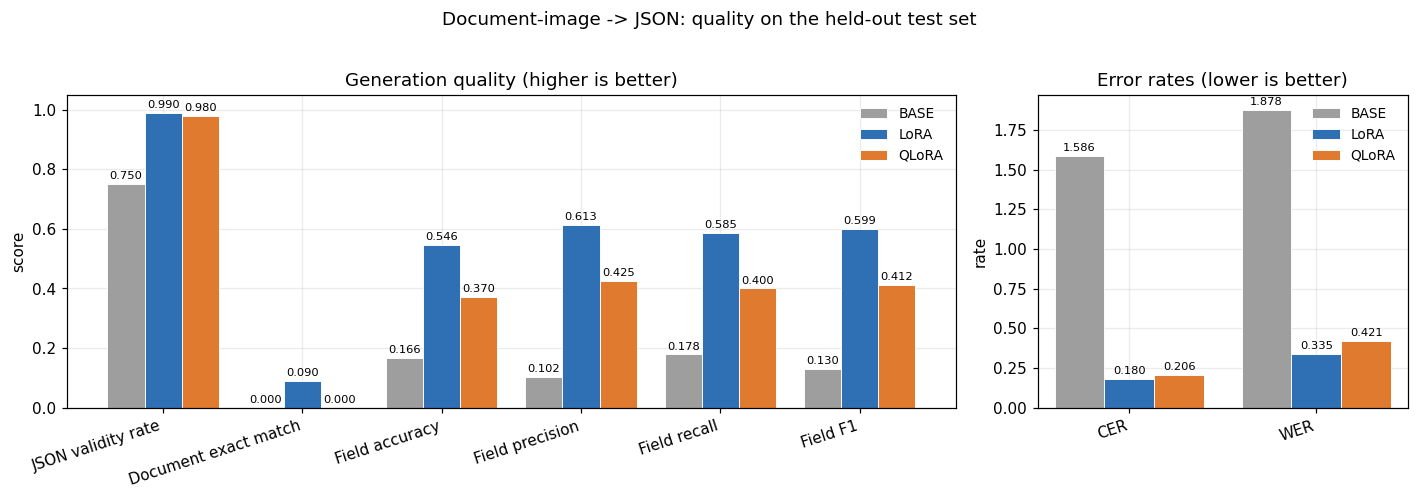

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4),
                         gridspec_kw={"width_ratios": [3, 1.25]})

grouped_bars(axes[0],
             ["json_validity_rate", "document_exact_match", "field_accuracy",
              "field_precision", "field_recall", "field_f1"],
             "Generation quality (higher is better)", "score")
axes[0].set_ylim(0, 1.05)

grouped_bars(axes[1], ["cer", "wer"], "Error rates (lower is better)", "rate")

fig.suptitle("Document-image -> JSON: quality on the held-out test set", y=1.02, fontsize=12)
fig.tight_layout()
plt.show()

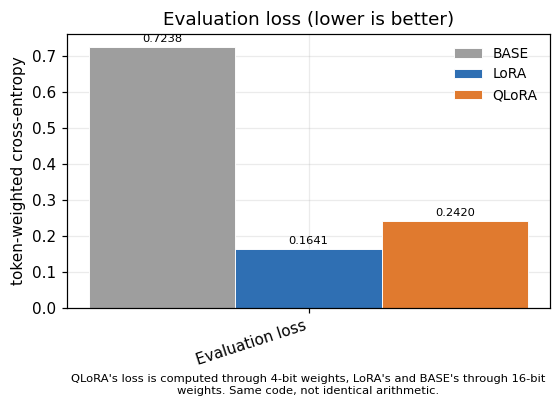

In [ ]:
fig, ax = plt.subplots(figsize=(5.2, 3.8))
grouped_bars(ax, ["eval_loss"], "Evaluation loss (lower is better)", "token-weighted cross-entropy",
             fmt="{:.4f}")
note = ("QLoRA's loss is computed through 4-bit weights, LoRA's and BASE's through 16-bit weights. "
        "Same code, not identical arithmetic.")
ax.set_xlabel(note, fontsize=7.5, wrap=True)
fig.tight_layout()
plt.show()

## 10 · Fine-tuning loss curves

LoRA and QLoRA only. **BASE is absent by design** — it is never trained, so it has no loss curve and
must not be given a fabricated one.

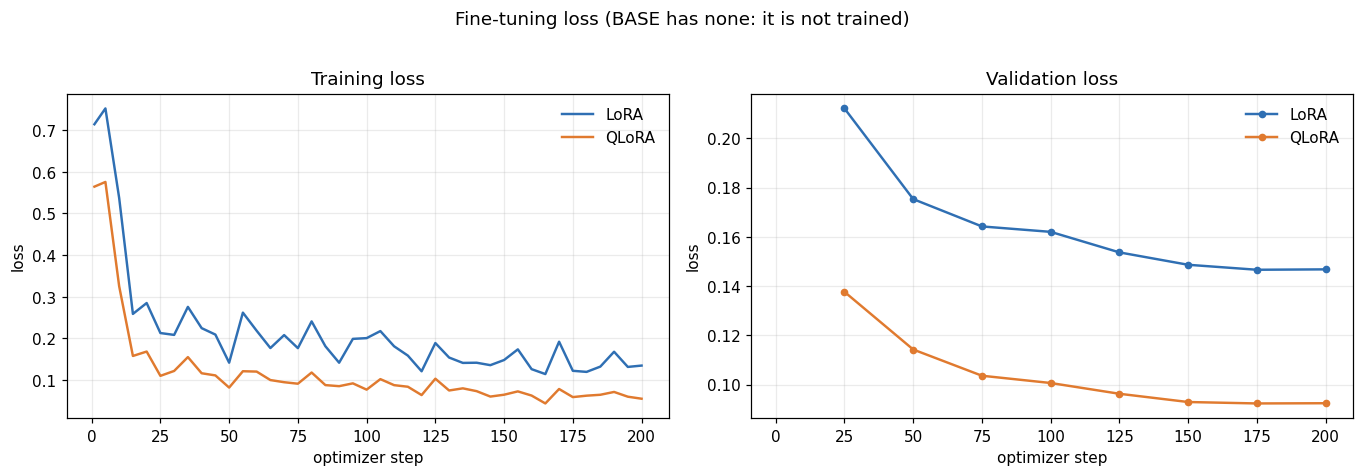

In [ ]:
curves = report.load_loss_curves(OUTPUT_ROOT)

if not curves:
    print("No training logs found — run the training cells first.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2), sharex=True)
    for method, series in curves.items():
        colour = VARIANT_COLOR[method]
        train = series["train"]
        if train:
            axes[0].plot([p["step"] for p in train], [p["loss"] for p in train],
                         color=colour, label=VARIANT_LABEL[method], linewidth=1.6)
        evals = series["eval"]
        if evals:
            axes[1].plot([p["step"] for p in evals], [p["loss"] for p in evals],
                         color=colour, label=VARIANT_LABEL[method],
                         marker="o", markersize=4, linewidth=1.6)
    axes[0].set_title("Training loss")
    axes[1].set_title("Validation loss")
    for ax in axes:
        ax.set_xlabel("optimizer step")
        ax.set_ylabel("loss")
        ax.legend(frameon=False)
    fig.suptitle("Fine-tuning loss (BASE has none: it is not trained)", y=1.02, fontsize=12)
    fig.tight_layout()
    plt.show()

## 11 · Resource cost — LoRA vs QLoRA

BASE is omitted from the first two panels because it has no training run at all; that is *not
applicable*, not zero. It does appear in the parameter panels, where its trainable count is 0 by
definition.

Note the distinction the parameter panels preserve: LoRA and QLoRA should report the **same total
parameter count**. Quantization changes the memory *footprint* of the base weights, not how many
parameters exist.

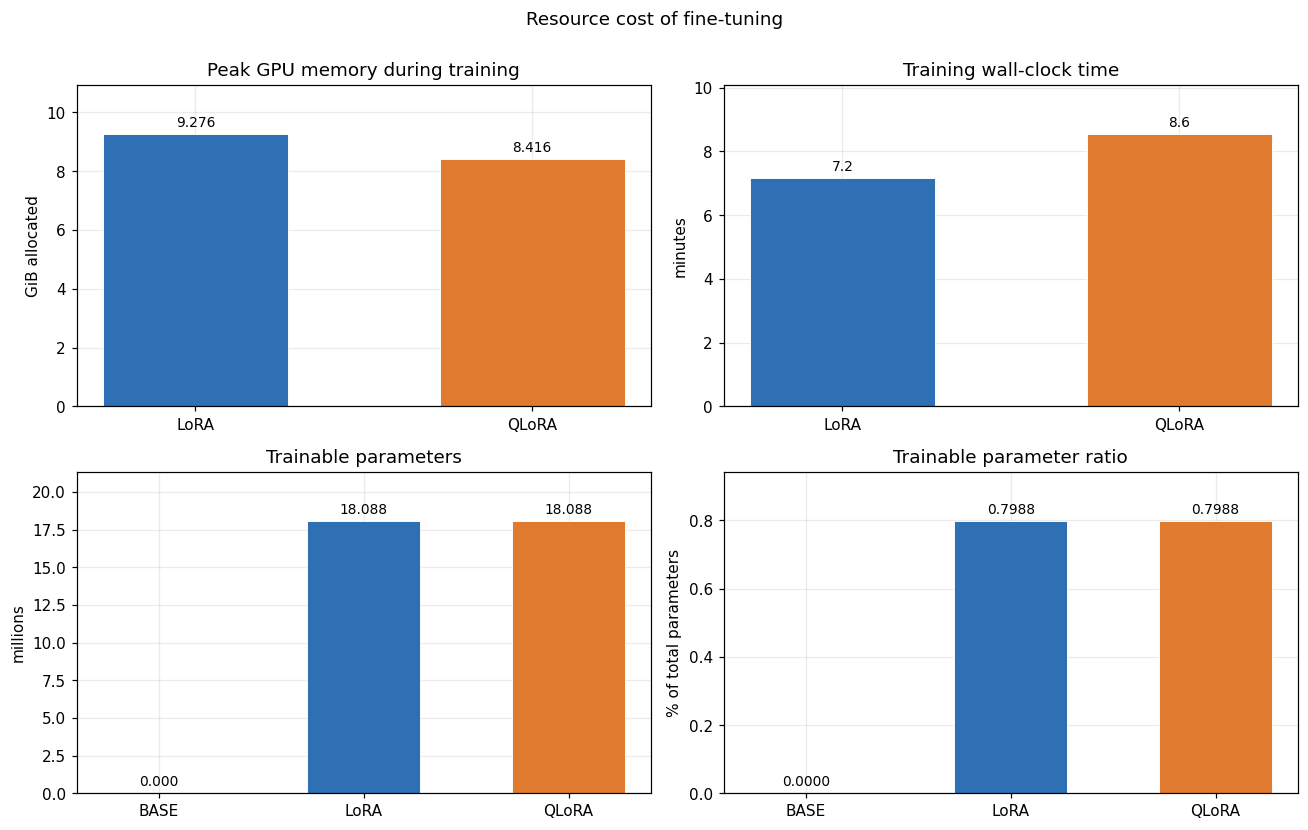

Total parameter count (must be equal for LoRA and QLoRA — quantization changes footprint, not count):
  BASE   2,246,272,880
  LoRA   2,264,360,816
  QLoRA  2,264,360,816
  LoRA   base-weight memory footprint: 4.251 GiB
  QLoRA  base-weight memory footprint: 1.776 GiB


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7.5))

def single_bars(ax, key, title, ylabel, variants, fmt="{:,.2f}", scale=1.0):
    vals = values_for(key)
    labels = [VARIANT_LABEL[v] for v in variants]
    raw = [vals[v] for v in variants]
    heights = [0.0 if v is None else float(v) / scale for v in raw]
    bars = ax.bar(labels, heights, color=[VARIANT_COLOR[v] for v in variants],
                  width=0.55, edgecolor="white", linewidth=0.6)
    for rect, value in zip(bars, raw):
        ax.annotate("N/A" if value is None else fmt.format(value / scale),
                    (rect.get_x() + rect.get_width() / 2, rect.get_height()),
                    textcoords="offset points", xytext=(0, 3), ha="center", va="bottom", fontsize=9)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.margins(y=0.18)

single_bars(axes[0][0], "peak_training_vram_gib", "Peak GPU memory during training",
            "GiB allocated", ["lora", "qlora"], "{:.3f}")
single_bars(axes[0][1], "training_duration_seconds", "Training wall-clock time",
            "minutes", ["lora", "qlora"], "{:.1f}", scale=60.0)
single_bars(axes[1][0], "trainable_parameters", "Trainable parameters",
            "millions", VARIANT_ORDER, "{:.3f}", scale=1e6)
single_bars(axes[1][1], "trainable_percent", "Trainable parameter ratio",
            "% of total parameters", VARIANT_ORDER, "{:.4f}")

fig.suptitle("Resource cost of fine-tuning", y=1.00, fontsize=12)
fig.tight_layout()
plt.show()

totals = values_for("total_parameters")
print("Total parameter count (must be equal for LoRA and QLoRA — "
      "quantization changes footprint, not count):")
for variant in VARIANT_ORDER:
    value = totals[variant]
    print(f"  {VARIANT_LABEL[variant]:<6} {'N/A' if value is None else f'{int(value):,}'}")
for method in ("lora", "qlora"):
    footprint = variants[method].get("training_parameters", {}).get("parameter_memory_gib")
    if footprint is not None:
        print(f"  {VARIANT_LABEL[method]:<6} base-weight memory footprint: {footprint:.3f} GiB")

## 12 · Quality versus cost

The point of the experiment. A method that gives up a little F1 for a large VRAM reduction may still
be the better practical choice; the plots below are what makes that judgement possible instead of
looking at quality alone.

BASE is drawn as a horizontal reference line because its training cost is zero — it sits at the
origin of the cost axis by definition, not because of a measurement.

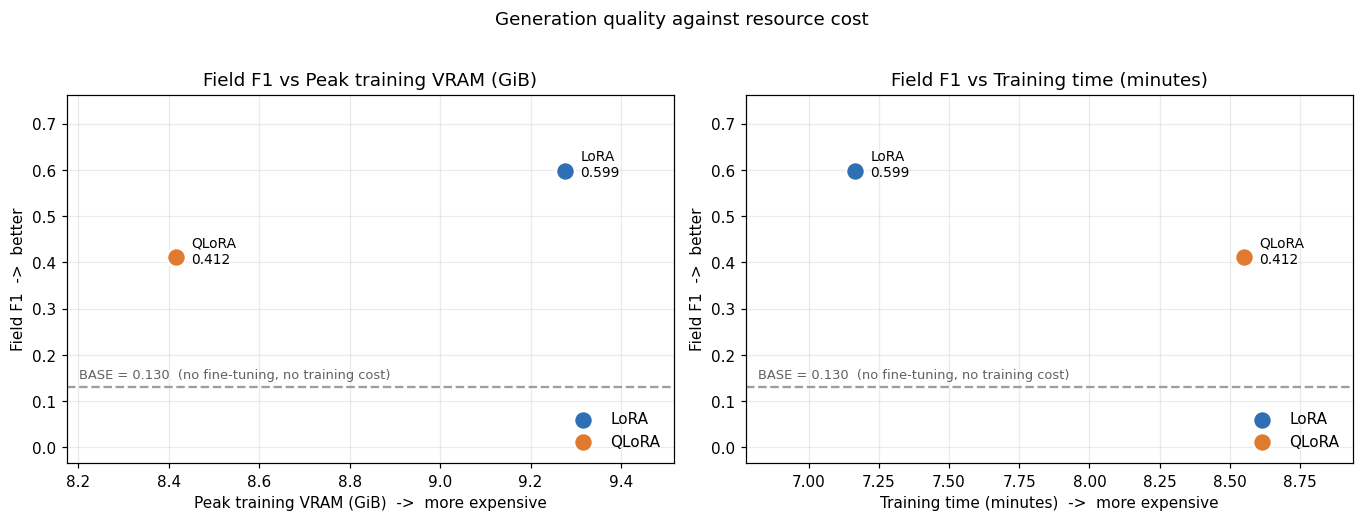

In [ ]:
quality_key = "field_f1"
quality = values_for(quality_key)

cost_panels = [
    ("peak_training_vram_gib", "Peak training VRAM (GiB)"),
    ("training_duration_seconds", "Training time (minutes)"),
]

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6))
for ax, (cost_key, cost_label) in zip(axes, cost_panels):
    costs = values_for(cost_key)
    scale = 60.0 if cost_key == "training_duration_seconds" else 1.0

    if quality["base"] is not None:
        ax.axhline(quality["base"], color=VARIANT_COLOR["base"], linestyle="--", linewidth=1.5)
        ax.annotate(f"BASE = {quality['base']:.3f}  (no fine-tuning, no training cost)",
                    (0.02, quality["base"]), xycoords=("axes fraction", "data"),
                    textcoords="offset points", xytext=(0, 6),
                    color="#616161", fontsize=8.5)

    plotted = False
    for method in ("lora", "qlora"):
        x, y = costs[method], quality[method]
        if x is None or y is None:
            continue
        plotted = True
        ax.scatter(x / scale, y, s=150, color=VARIANT_COLOR[method],
                   edgecolor="white", linewidth=1.5, zorder=3, label=VARIANT_LABEL[method])
        ax.annotate(f"{VARIANT_LABEL[method]}\n{y:.3f}", (x / scale, y),
                    textcoords="offset points", xytext=(10, -4), fontsize=9)

    ax.set_xlabel(cost_label + "  ->  more expensive")
    ax.set_ylabel(_ROWS[quality_key]["metric"] + "  ->  better")
    ax.set_title(f"{_ROWS[quality_key]['metric']} vs {cost_label}")
    if plotted:
        ax.legend(frameon=False, loc="lower right")
        ax.margins(x=0.28, y=0.35)
    else:
        ax.text(0.5, 0.5, "not measured", ha="center", va="center", transform=ax.transAxes)

fig.suptitle("Generation quality against resource cost", y=1.02, fontsize=12)
fig.tight_layout()
plt.show()

## 13 · Example predictions

A qualitative spot-check of what the metrics are summarising.

In [ ]:
import itertools, os, textwrap

def load_predictions(variant):
    path = report.artifact_paths(OUTPUT_ROOT, variant)["predictions"]
    if not os.path.isfile(path):
        return []
    with open(path, encoding="utf-8") as handle:
        return [json.loads(line) for line in handle]

preds = {variant: load_predictions(variant) for variant in VARIANT_ORDER}
available = [v for v in VARIANT_ORDER if preds[v]]

if not available:
    print("No predictions yet — run the evaluation cells first.")
else:
    for index in range(min(2, len(preds[available[0]]))):
        print("=" * 100)
        print(f"DOCUMENT {index}")
        print("-" * 100)
        print("REFERENCE:")
        print(textwrap.fill(preds[available[0]][index]["reference"], 100, subsequent_indent="  "))
        for variant in available:
            record = preds[variant][index]
            flags = f"json_valid={record['json_valid']} exact={record['exact_match']} " \
                    f"fields={record['matched_fields']}/{record['reference_fields']}"
            print(f"\n{VARIANT_LABEL[variant]}  [{flags}]")
            print(textwrap.fill(record["prediction_raw"][:900] or "(empty)", 100, subsequent_indent="  "))
        print()

DOCUMENT 0
----------------------------------------------------------------------------------------------------
REFERENCE:
{"menu": [{"cnt": "2", "itemsubtotal": "60.000", "nm": "-TICKET CP", "num": "901016", "price":
  "60.000"}], "sub_total": {"discount_price": "-60.000", "subtotal_price": "60.000", "tax_price":
  "5.455"}, "total": {"creditcardprice": "60.000", "menuqty_cnt": "2.00", "total_price": "60.000"}}

BASE  [json_valid=True exact=False fields=2/11]
{     "menu": [         {             "nm": "TICKET",             "num": "901016",
  "cnt": "2",             "unitprice": "60.00",             "price": "60.00",
  "discountprice": "-",             "subtotal_price": "5.15",             "sub_nm": "etc",
  "sub_cnt": "2",             "sub_unitprice": "etc",             "sub_price": "etc",
  "etc": "etc"         }     ],     "sub_total": {         "subtotal_price": "5.15",
  "discountprice": "-",         "service_price": "etc",         "othersvc_price": "etc",
  "tax_price": "etc",  

## 14 · Final analysis

Every number below is read from the artifacts. Where something was not measured it says so rather
than guessing, and no conclusion is asserted that the measurements do not support.

In [ ]:
import math

HEADLINE = [(k, lbl, hib) for k, lbl, hib in
            __import__("vlm_ft.metrics", fromlist=["metrics"]).HEADLINE_METRICS]

q = {variant: variants[variant]["quality"] for variant in VARIANT_ORDER}
deltas = analysis["quality_deltas"]
n_test = (variants["base"].get("dataset") or {}).get("examples")

def num(value, spec="{:.4f}"):
    return "N/A" if value is None else spec.format(value)

def signed(value, spec="{:+.4f}"):
    return "N/A" if value is None else spec.format(value)

def relative(value):
    return "N/A" if value is None else f"{value * 100:+.1f}%"

def improvement_line(key, label, higher_is_better, pair):
    change = deltas[pair][key]
    frm = "lora" if pair == "qlora_vs_lora" else "base"
    to = pair.split("_vs_")[0]
    a, b = q[frm].get(key), q[to].get(key)
    if a is None or b is None:
        return f"  {label:<22} not measured"
    direction = "better" if ((change['absolute'] > 0) == higher_is_better) else "worse"
    if abs(change["absolute"]) < 1e-12:
        direction = "unchanged"
    return (f"  {label:<22} {num(a)} -> {num(b)}   "
            f"delta {signed(change['absolute'])} ({relative(change['relative'])})  {direction}")

def section(title):
    print("\n" + "=" * 92)
    print(title)
    print("=" * 92)

# ---------------------------------------------------------------- Q1 / Q2
for number, (pair, title) in enumerate(
        [("lora_vs_base", "1. How much does LoRA improve structured JSON generation over BASE?"),
         ("qlora_vs_base", "2. How much does QLoRA improve structured JSON generation over BASE?")], 1):
    section(title)
    for key, label, higher_is_better in HEADLINE:
        print(improvement_line(key, label, higher_is_better, pair))

# ------------------------------------------------------------------- Q3
section("3. Is there a meaningful quality difference between LoRA and QLoRA?")
for key, label, higher_is_better in HEADLINE:
    print(improvement_line(key, label, higher_is_better, "qlora_vs_lora"))

print("\n  Share of LoRA's gain over BASE that QLoRA retains:")
retentions = []
for key, label, higher_is_better in HEADLINE:
    base_v, lora_v, qlora_v = q["base"].get(key), q["lora"].get(key), q["qlora"].get(key)
    if None in (base_v, lora_v, qlora_v):
        print(f"    {label:<22} not measured")
        continue
    lora_gain = (lora_v - base_v) if higher_is_better else (base_v - lora_v)
    qlora_gain = (qlora_v - base_v) if higher_is_better else (base_v - qlora_v)
    if abs(lora_gain) < 1e-9:
        print(f"    {label:<22} LoRA did not move this metric; retention undefined")
        continue
    ratio = qlora_gain / lora_gain
    retentions.append(ratio)
    print(f"    {label:<22} {ratio * 100:6.1f}%")

if n_test:
    print(f"\n  Resolution of this test set (n = {n_test} documents):")
    for key, label in (("document_exact_match", "Document exact match"),
                       ("json_validity_rate", "JSON validity rate")):
        p = q["lora"].get(key)
        if p is None:
            continue
        se = math.sqrt(max(p * (1 - p), 0.0) / n_test)
        print(f"    {label:<22} standard error ~{se:.4f}; differences below roughly "
              f"{2 * se:.3f} are not resolvable at this sample size")

# ------------------------------------------------------------------- Q4
section("4. How much GPU VRAM does QLoRA save compared with LoRA?")
vram = analysis["vram"]
if not vram["measured"]:
    reason = (variants["lora"].get("resources", {}).get("gpu_unavailable_reason")
              or "one or both training runs are missing")
    print(f"  Not measured: {reason}")
else:
    print(f"  LoRA  peak allocated : {vram['lora_peak_gib']:.3f} GiB")
    print(f"  QLoRA peak allocated : {vram['qlora_peak_gib']:.3f} GiB")
    print(f"  Saving               : {vram['qlora_saving_gib']:+.3f} GiB "
          f"({vram['qlora_saving_percent']:+.1f}% relative to LoRA)")
    for method in ("lora", "qlora"):
        res = variants[method]["resources"]
        print(f"    {VARIANT_LABEL[method]:<6} reserved peak {num(res.get('peak_training_vram_reserved_gib'), '{:.3f}')} GiB"
              f" | after model load {num(res.get('model_load_peak_vram_gib'), '{:.3f}')} GiB"
              f" | GPU {res.get('gpu_name')} ({num(res.get('total_vram_gib'), '{:.1f}')} GiB total)")

# ------------------------------------------------------------------- Q5
section("5. How do LoRA and QLoRA differ in training time?")
timing = analysis["training_time"]
if not timing["measured"]:
    print("  Not measured: one or both training runs are missing.")
else:
    print(f"  LoRA  : {timing['lora_seconds']:,.1f}s ({timing['lora_human']})")
    print(f"  QLoRA : {timing['qlora_seconds']:,.1f}s ({timing['qlora_human']})")
    print(f"  QLoRA overhead: {timing['qlora_overhead_seconds']:+,.1f}s "
          f"({timing['qlora_overhead_percent']:+.1f}%)")
    print(f"  Excluding in-training validation: LoRA {num(timing['lora_seconds_excluding_eval'], '{:,.1f}')}s"
          f" vs QLoRA {num(timing['qlora_seconds_excluding_eval'], '{:,.1f}')}s")
    for method in ("lora", "qlora"):
        res = variants[method]["resources"]
        print(f"    {VARIANT_LABEL[method]:<6} {res.get('steps')} steps, "
              f"{num(res.get('steps_per_second'), '{:.3f}')} steps/s, "
              f"{num(res.get('samples_per_second'), '{:.3f}')} samples/s; "
              f"model prep (excluded) {num(res.get('model_preparation_seconds'), '{:.1f}')}s")

# ------------------------------------------------------------------- Q6
section("6. Do LoRA and QLoRA have the expected similar number of trainable adapter parameters?")
params = analysis["parameters"]

def identical(flag):
    return "not comparable (a run is missing)" if flag is None else str(flag)

print(f"  LoRA  trainable : {num(params['lora_trainable'], '{:,.0f}')}")
print(f"  QLoRA trainable : {num(params['qlora_trainable'], '{:,.0f}')}")
print(f"  Identical       : {identical(params['trainable_identical'])}")
print(f"  LoRA  total     : {num(params['lora_total'], '{:,.0f}')}")
print(f"  QLoRA total     : {num(params['qlora_total'], '{:,.0f}')}")
print(f"  Identical       : {identical(params['total_identical'])}")
print(f"  BASE  trainable : {num(params['base_trainable'], '{:,.0f}')}  (0 by definition: not fine-tuned)")
print(f"\n  {params['note']}")
print(f"  Base-weight memory footprint: LoRA {num(params['lora_parameter_memory_gib'], '{:.3f}')} GiB"
      f" vs QLoRA {num(params['qlora_parameter_memory_gib'], '{:.3f}')} GiB")

# ------------------------------------------------------------------- Q7
section("7. Does any quality difference justify LoRA's extra resource cost?")
f1 = {v: q[v].get("field_f1") for v in VARIANT_ORDER}
if None in (f1["base"], f1["lora"], f1["qlora"]) or not vram["measured"] or not timing["measured"]:
    print("  Cannot be answered yet: the quality and resource measurements are not all present.")
else:
    lora_gain = f1["lora"] - f1["base"]
    qlora_gain = f1["qlora"] - f1["base"]
    retention = (qlora_gain / lora_gain) if abs(lora_gain) > 1e-9 else None
    print(f"  Field F1:  BASE {f1['base']:.4f} -> LoRA {f1['lora']:.4f} / QLoRA {f1['qlora']:.4f}")
    print(f"  LoRA gain over BASE : {lora_gain:+.4f}")
    print(f"  QLoRA gain over BASE: {qlora_gain:+.4f}"
          + (f"  ({retention * 100:.1f}% of LoRA's gain)" if retention is not None else ""))
    print(f"  QLoRA vs LoRA F1    : {f1['qlora'] - f1['lora']:+.4f}")
    print()
    print(f"  Cost of that difference:")
    print(f"    peak training VRAM : QLoRA uses {vram['qlora_saving_percent']:+.1f}% "
          f"({vram['qlora_saving_gib']:+.3f} GiB) versus LoRA")
    print(f"    training time      : QLoRA takes {timing['qlora_overhead_percent']:+.1f}% "
          f"({timing['qlora_overhead_seconds']:+,.0f}s) versus LoRA")
    print()
    print("  Read this as a trade-off, not a ranking. The two methods buy different things:")
    print("  QLoRA trades some quality (measured above) for a lower memory ceiling; LoRA trades")
    print("  memory for whatever quality difference the numbers above actually show. Which one")
    print("  wins depends on the binding constraint -- if the model does not fit in the available")
    print("  VRAM under LoRA, its quality advantage is unavailable at any price; if it does fit,")
    print("  the quality gap is what you are paying the extra memory for.")

section("Controlled-comparison status")
check = analysis["controlled_comparison"]
if check.get("checked"):
    print("  All matched." if check["all_matched"]
          else f"  MISMATCH: {check['failed']} -- the comparison above is confounded; fix before concluding.")
else:
    print(f"  Not checked: {check.get('reason')}")


1. How much does LoRA improve structured JSON generation over BASE?
  JSON validity rate     0.7500 -> 0.9900   delta +0.2400 (+32.0%)  better
  Document exact match   0.0000 -> 0.0900   delta +0.0900 (N/A)  better
  Field accuracy         0.1660 -> 0.5457   delta +0.3797 (+228.7%)  better
  Field precision        0.1024 -> 0.6132   delta +0.5108 (+498.9%)  better
  Field recall           0.1783 -> 0.5849   delta +0.4066 (+228.0%)  better
  Field F1               0.1301 -> 0.5987   delta +0.4687 (+360.3%)  better
  CER                    1.5862 -> 0.1803   delta -1.4060 (-88.6%)  better
  WER                    1.8781 -> 0.3353   delta -1.5428 (-82.1%)  better
  Evaluation loss        0.7238 -> 0.1641   delta -0.5597 (-77.3%)  better

2. How much does QLoRA improve structured JSON generation over BASE?
  JSON validity rate     0.7500 -> 0.9800   delta +0.2300 (+30.7%)  better
  Document exact match   0.0000 -> 0.0000   delta +0.0000 (N/A)  unchanged
  Field accuracy         0.1660 -> 

## 15 · How to read these results, and what they do not show

**What is controlled.** Both fine-tuning runs go through one entry point with one shared config
parent, one dataset, one prompt, one target format, one seed, one adapter configuration and one
optimizer. Section 7 verifies this against what the finished runs actually recorded, including a
hash of the module names LoRA wrapped on each instantiated model.

**What cannot be controlled**, and is listed with reasons in section 7:

- QLoRA stores base weights in 4-bit NF4 — that is the independent variable, not a confound.
- `prepare_model_for_kbit_training` runs only for QLoRA; it has no meaning for an unquantized base.
- QLoRA is scored against 4-bit weights by default, because that is its deployable form. Re-run the
  QLoRA evaluation with `--quantization none` to separate the training effect from the inference one.
- Evaluation loss is produced by identical code but not identical arithmetic, since the forward
  passes run through different weight precisions.

**Single-run caveat.** Each condition is one run at one seed. Differences of the same order as the
sampling noise reported in question 3 should not be read as real. To make a claim about a small
quality gap, re-run both methods across several seeds (`--set experiment.seed=...`) and compare the
spread — the artifact layout keeps runs separate if you also change `--output-dir`.

**VRAM caveat.** Peak allocated memory depends on sequence length, which depends on image resolution
and receipt length. The absolute GiB numbers are specific to this configuration; the LoRA/QLoRA
*ratio* is the portable finding.

**Metric caveat.** Field precision / recall / F1 are order-insensitive over `key.path = value` pairs,
so a correct line item still counts when an earlier item was missed. Field accuracy is the stricter
position-aware variant, and the two moving differently tells you whether errors are wrong *values*
or wrong *structure*. CER and WER are computed over the canonical serialized JSON, falling back to
the raw generation when the output is not parseable — so an almost-right but malformed output scores
better than silence.

In [ ]:
# Persist the merged comparison so it can be reloaded without re-running anything.
!python scripts/collect_results.py --quiet
print("\nwrote:", OUTPUT_ROOT + "/comparison/{comparison.json,comparison.csv,comparison.md,loss_curves.json}")


wrote outputs/comparison/comparison.{json,csv,md}

wrote: outputs/comparison/{comparison.json,comparison.csv,comparison.md,loss_curves.json}


---

## 16 · Multi-seed study

Everything above is a single run at one seed. That is enough to see whether fine-tuning helps at
all, but **not** enough to say whether a small LoRA-vs-QLoRA gap is real — question 3 above prints
the sampling noise that a 100-document test set carries.

This section runs the whole matrix across several seeds and compares the methods *pairwise*: both
methods see the same seed list, so the per-seed difference is the unit of comparison.

`scripts/run_experiment.py` is orchestration only — it shells out to the same `train.py` and
`evaluate.py` used above, writing into `<output_root>/seed<N>/`. Interrupted studies resume: a step
whose artifact already exists is skipped unless you pass `--force`.

**Cost.** 3 seeds × (2 trainings + 3 evaluations) = 15 steps. On an A100 budget several hours.
Validate the plumbing first with `--smoke` (a couple of minutes, results meaningless):

```
!python scripts/run_experiment.py --seeds 42 43 44 --smoke
```

In [ ]:
SEEDS = [42, 43, 44]

# Dry run first: prints the exact commands without executing them.
!python scripts/run_experiment.py --seeds {" ".join(map(str, SEEDS))} --dry-run

2026-09-12 17:12:15,553 INFO run_experiment | seeds=[42, 43, 44] methods=['lora', 'qlora'] variants=['base', 'lora', 'qlora'] -> 15 steps under outputs
2026-09-12 17:12:15,553 INFO run_experiment | [1/15] seed 42 | train lora
+ /usr/bin/python3 /content/vlm-lora-qlora-comparison/scripts/train.py --method lora --set experiment.seed=42 --set experiment.output_root=outputs/seed42
2026-09-12 17:12:15,553 INFO run_experiment | [2/15] seed 42 | train qlora
+ /usr/bin/python3 /content/vlm-lora-qlora-comparison/scripts/train.py --method qlora --set experiment.seed=42 --set experiment.output_root=outputs/seed42
2026-09-12 17:12:15,553 INFO run_experiment | [3/15] seed 42 | evaluate base
+ /usr/bin/python3 /content/vlm-lora-qlora-comparison/scripts/evaluate.py --model-variant base --set experiment.seed=42 --set experiment.output_root=outputs/seed42
2026-09-12 17:12:15,553 INFO run_experiment | [4/15] seed 42 | evaluate lora
+ /usr/bin/python3 /content/vlm-lora-qlora-comparison/scripts/evaluate.p

In [ ]:
# The real study. Hours of compute -- run the dry run and a --smoke pass first.
!python scripts/run_experiment.py --seeds {" ".join(map(str, SEEDS))}

2026-09-12 17:12:15,756 INFO run_experiment | seeds=[42, 43, 44] methods=['lora', 'qlora'] variants=['base', 'lora', 'qlora'] -> 15 steps under outputs
2026-09-12 17:12:15,756 INFO run_experiment | [1/15] seed 42 | train lora
+ /usr/bin/python3 /content/vlm-lora-qlora-comparison/scripts/train.py --method lora --set experiment.seed=42 --set experiment.output_root=outputs/seed42
2026-09-12 17:12:15,866 INFO train | method=lora (base weights held in the 16-bit compute dtype; LoRA adapters trained)
2026-09-12 17:12:15,867 INFO train | config=/content/vlm-lora-qlora-comparison/scripts/../configs/lora.yaml output=outputs/seed42/lora
2026-09-12 17:12:22,049 INFO numexpr.utils | NumExpr defaulting to 12 threads.
2026-09-12 17:12:24,115 INFO train | compute dtype=bfloat16
2026-09-12 17:12:24,154 INFO datasets | TensorFlow version 2.20.0 available.
2026-09-12 17:12:24,155 INFO datasets | JAX version 0.11.1 available.
2026-09-12 17:12:24,626 INFO httpx | HTTP Request: HEAD https://huggingface.co/

### 16a · Results across seeds

In [ ]:
try:
    from IPython.display import display          # present in Colab/Jupyter
except ImportError:                              # plain-python execution
    display = print

ms = report.build_multi_seed_comparison(OUTPUT_ROOT, SEEDS)

print("seeds found  :", ms["seeds_found"])
print("seeds missing:", ms["seeds_missing"] or "none")

if not ms["seeds_found"]:
    print("\nNo per-seed artifacts yet. Run the cell above first.")
else:
    ms_table = pd.DataFrame([
        {
            "Metric": row["metric"],
            **{VARIANT_LABEL[v]: report.format_stats(row["key"], row[v]) for v in VARIANT_ORDER},
        }
        for row in ms["table"]
    ])
    print(f"\nmean ± sample std over seeds {ms['seeds_found']}")
    display(ms_table)

seeds found  : [42, 43, 44]
seeds missing: none

mean ± sample std over seeds [42, 43, 44]


,Metric,BASE,LoRA,QLoRA
0,JSON validity rate,0.7500 ± 0.0000,0.9867 ± 0.0058,0.9767 ± 0.0115
1,Document exact match,0.0000 ± 0.0000,0.0967 ± 0.0058,0.0033 ± 0.0058
2,Field accuracy,0.1660 ± 0.0000,0.5450 ± 0.0081,0.3923 ± 0.0318
3,Field precision,0.1024 ± 0.0000,0.6112 ± 0.0147,0.4509 ± 0.0216
4,Field recall,0.1783 ± 0.0000,0.5844 ± 0.0058,0.4166 ± 0.0350
5,Field F1,0.1301 ± 0.0000,0.5975 ± 0.0094,0.4330 ± 0.0286
6,CER,1.5862 ± 0.0000,0.1738 ± 0.0041,0.2157 ± 0.0322
7,WER,1.8781 ± 0.0000,0.3298 ± 0.0032,0.4304 ± 0.0484
8,Evaluation loss,0.7238 ± 0.0000,0.1643 ± 0.0005,0.2413 ± 0.0018
9,Peak training VRAM (GiB),N/A,9.254 ± 0.038,8.394 ± 0.039


### 16b · Spread across seeds

Bars are the mean, whiskers the sample standard deviation, dots the individual seeds. If the dots
for LoRA and QLoRA overlap, the gap between their means is not something this study resolves.

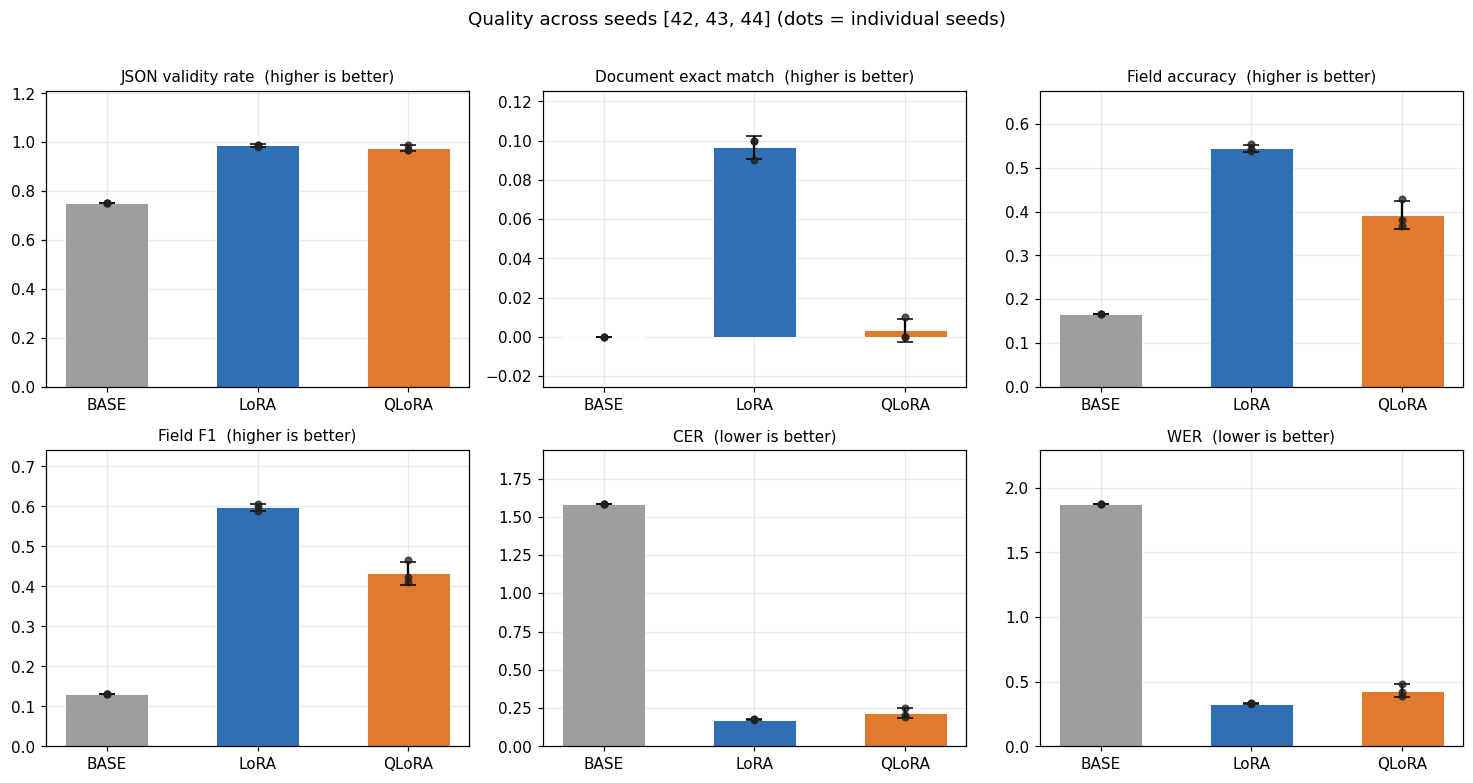

In [ ]:
if not ms["seeds_found"]:
    print("run the multi-seed study first")
else:
    ms_rows = {row["key"]: row for row in ms["table"]}
    keys = ["json_validity_rate", "document_exact_match", "field_accuracy", "field_f1", "cer", "wer"]

    fig, axes = plt.subplots(2, 3, figsize=(13.5, 7))
    for ax, key in zip(axes.ravel(), keys):
        row = ms_rows[key]
        labels, means, errors, colours = [], [], [], []
        for variant in VARIANT_ORDER:
            stats = row[variant]
            if stats["n"] == 0:
                continue
            labels.append(VARIANT_LABEL[variant])
            means.append(stats["mean"])
            errors.append(stats["std"] or 0.0)
            colours.append(VARIANT_COLOR[variant])
        if not labels:
            ax.text(0.5, 0.5, "not measured", ha="center", va="center", transform=ax.transAxes)
            ax.set_title(row["metric"])
            continue
        ax.bar(labels, means, yerr=errors, capsize=5, color=colours,
               width=0.55, edgecolor="white", linewidth=0.6)
        for x, variant in enumerate(v for v in VARIANT_ORDER if row[v]["n"]):
            values = row[variant]["values"]
            ax.scatter([x] * len(values), values, color="#212121", s=18, zorder=4, alpha=0.75)
        ax.set_title(f"{row['metric']}  ({'higher' if row['higher_is_better'] else 'lower'} is better)",
                     fontsize=10)
        ax.margins(y=0.22)
    fig.suptitle(f"Quality across seeds {ms['seeds_found']} (dots = individual seeds)", y=1.01)
    fig.tight_layout()
    plt.show()

### 16c · Paired LoRA vs QLoRA

Both methods ran on the same seeds, so each seed gives one paired difference. With a handful of
seeds, **sign consistency is the evidence** — "QLoRA is behind in 3 of 3 seeds" is interpretable,
whereas a p-value from three points would imply precision the data does not have.

In [ ]:
paired = ms["paired_lora_vs_qlora"]

if not ms["seeds_found"]:
    print("run the multi-seed study first")
else:
    # count seeds where BOTH methods produced a result, not seeds that merely exist
    n_paired = max((e["difference"]["n"] for e in paired["metrics"].values()), default=0)
    print(f"difference = QLoRA - LoRA, on the raw metric ({n_paired} paired seeds)\n")
    header = f"{'metric':<22} {'mean diff':>12} {'std':>10} {'favours':>28}"
    print(header)
    print("-" * len(header))
    for key, entry in paired["metrics"].items():
        diff = entry["difference"]
        if diff["n"] == 0:
            print(f"{entry['label']:<22} {'not measured':>12}")
            continue
        std = "n/a" if diff["std"] is None else f"{diff['std']:.4f}"
        if entry["all_tied"]:
            verdict = f"identical in all {diff['n']} seeds"
        else:
            verdict = (f"QLoRA {entry['seeds_favouring_candidate']}/{diff['n']}, "
                       f"LoRA {entry['seeds_favouring_baseline']}/{diff['n']}")
            if entry["sign_is_consistent"]:
                verdict += "  (consistent)"
        print(f"{entry['label']:<22} {diff['mean']:>+12.4f} {std:>10} {verdict:>28}")
    print("\n" + paired["note"])

difference = QLoRA - LoRA, on the raw metric (3 paired seeds)

metric                    mean diff        std                      favours
---------------------------------------------------------------------------
JSON validity rate          -0.0100     0.0100          QLoRA 0/3, LoRA 2/3
Document exact match        -0.0933     0.0058 QLoRA 0/3, LoRA 3/3  (consistent)
Field accuracy              -0.1527     0.0387 QLoRA 0/3, LoRA 3/3  (consistent)
Field precision             -0.1603     0.0362 QLoRA 0/3, LoRA 3/3  (consistent)
Field recall                -0.1678     0.0389 QLoRA 0/3, LoRA 3/3  (consistent)
Field F1                    -0.1645     0.0378 QLoRA 0/3, LoRA 3/3  (consistent)
CER                         +0.0419     0.0289 QLoRA 0/3, LoRA 3/3  (consistent)
WER                         +0.1006     0.0461 QLoRA 0/3, LoRA 3/3  (consistent)
Evaluation loss             +0.0770     0.0023 QLoRA 0/3, LoRA 3/3  (consistent)

Differences are candidate minus baseline on the raw metric. 

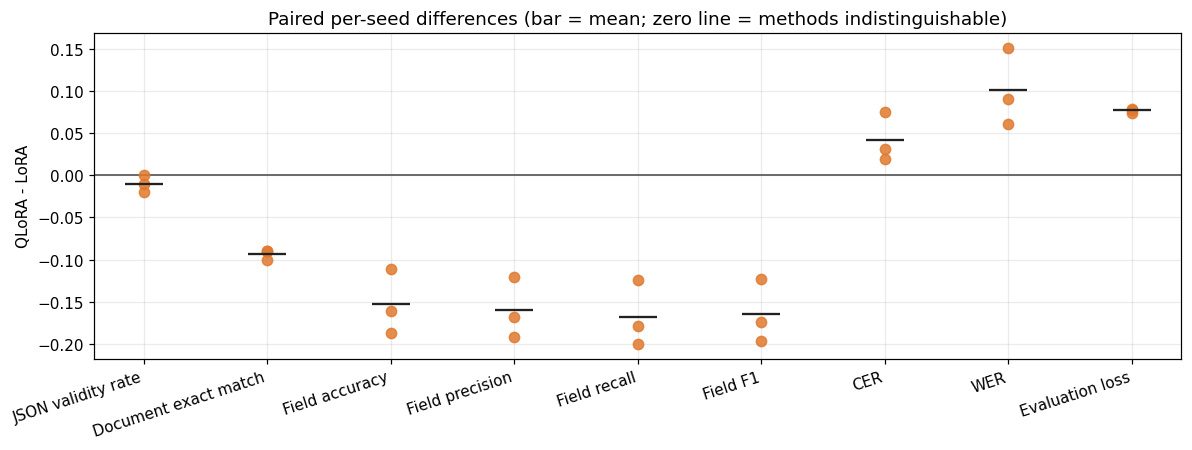

In [ ]:
if ms["seeds_found"]:
    keys = [k for k, e in paired["metrics"].items() if e["difference"]["n"] > 0]
    if keys:
        fig, ax = plt.subplots(figsize=(11, 4.2))
        positions = range(len(keys))
        for x, key in zip(positions, keys):
            entry = paired["metrics"][key]
            values = [e["difference"] for e in entry["per_seed"]]
            ax.scatter([x] * len(values), values, color=VARIANT_COLOR["qlora"],
                       s=45, zorder=3, alpha=0.85)
            ax.scatter([x], [entry["difference"]["mean"]], color="#212121",
                       marker="_", s=600, zorder=4)
        ax.axhline(0, color="#616161", linewidth=1.2)
        ax.set_xticks(list(positions))
        ax.set_xticklabels([paired["metrics"][k]["label"] for k in keys], rotation=18, ha="right")
        ax.set_ylabel("QLoRA - LoRA")
        ax.set_title("Paired per-seed differences (bar = mean; zero line = methods indistinguishable)")
        fig.tight_layout()
        plt.show()

### 16d · Resource cost across seeds, and the controlled-comparison check

In [ ]:
if not ms["seeds_found"]:
    print("run the multi-seed study first")
else:
    for key, unit, scale in (("peak_training_vram_gib", "GiB", 1.0),
                             ("training_duration_seconds", "min", 60.0)):
        row = ms_rows[key]
        print(f"{row['metric']}:")
        for method in ("lora", "qlora"):
            stats = row[method]
            if stats["n"] == 0:
                print(f"  {VARIANT_LABEL[method]:<6} not measured")
                continue
            spread = "n/a" if stats["std"] is None else f"{stats['std'] / scale:.3f}"
            values = ", ".join(f"{v / scale:.2f}" for v in stats["values"])
            print(f"  {VARIANT_LABEL[method]:<6} mean {stats['mean'] / scale:8.3f} {unit}"
                  f"  ± {spread}   per seed: [{values}]")
        print()

    check = ms["controlled_comparison"]
    if check["all_seeds_matched"] is None:
        print("Controlled comparison: not checked (needs both a LoRA and a QLoRA artifact)")
    else:
        print(f"Controlled comparison: seeds {check['seeds_checked']} -> "
              f"{'ALL MATCHED' if check['all_seeds_matched'] else 'MISMATCH in ' + str(check['failed_seeds'])}")
    print(f"GPUs used across seeds: {check['gpu_names_seen'] or 'none recorded'}")
    if check["gpu_warning"]:
        print(f"WARNING: {check['gpu_warning']}")
    else:
        print("All seeds ran on the same GPU model, so the pooled resource statistics are comparable.")

Peak training VRAM (GiB):
  LoRA   mean    9.254 GiB  ± 0.038   per seed: [9.28, 9.28, 9.21]
  QLoRA  mean    8.394 GiB  ± 0.039   per seed: [8.42, 8.42, 8.35]

Training time (s):
  LoRA   mean    7.198 min  ± 0.045   per seed: [7.15, 7.23, 7.21]
  QLoRA  mean    8.608 min  ± 0.042   per seed: [8.56, 8.64, 8.62]

Controlled comparison: seeds [42, 43, 44] -> ALL MATCHED
GPUs used across seeds: ['NVIDIA A100-SXM4-80GB']
All seeds ran on the same GPU model, so the pooled resource statistics are comparable.


### 16e · What the multi-seed study licenses you to say

- A quality difference whose **sign flips across seeds** is not a difference this study can resolve.
  Report it as "no measurable difference", not as a small win for either method.
- A difference that is **consistent in sign across every seed** is evidence of a real effect, though
  three seeds still say little about its magnitude.
- **VRAM and training time barely vary across seeds** — the data order changes, the memory ceiling
  and the step count do not. A large spread there points at a confound (a different GPU, a busy
  machine, a changed config) rather than at seed noise.
- Trainable and total parameter counts must be **identical** across seeds and across methods. Any
  spread there is a bug, not a finding.